# Reference Embedding Precompute

이 노트북은 이미 학습된 `scratch` / `embedding` TFLite encoder를 각 `reference.npy`에 적용해서, 서비스 런타임에서 재사용할 reference embedding cache를 만든다.

핵심 아이디어:

```text
reference.npy의 30프레임 window
→ TFLite encoder
→ reference embedding vector
→ data/cache/reference_embeddings/*.npz 저장
```

서비스 중에는 유저 window만 실시간 TFLite 추론하고, reference 쪽은 이 cache에서 벡터를 꺼내 cosine similarity만 계산하도록 최적화할 수 있다.


## 0. 환경 설정

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
candidates = [start, *start.parents]
for base in [start, *start.parents]:
    candidates.extend([
        base / 'boot_env' / 'pjt_main',
        base / 'pjt_main',
    ])

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / 'scripts' / 'precompute_reference_embeddings.py').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('pjt_main project root를 찾지 못했습니다.')

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

SCRIPT = PROJECT_ROOT / 'scripts' / 'precompute_reference_embeddings.py'
DATA_DIR = PROJECT_ROOT / 'data' / 'reference_dances'
SCRATCH_MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'scratch'
EMBEDDING_MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'embedding'
CACHE_DIR = PROJECT_ROOT / 'data' / 'cache' / 'reference_embeddings'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SCRIPT =', SCRIPT)
print('CACHE_DIR =', CACHE_DIR)
print('PYTHON =', sys.executable)


PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_main
SCRIPT = /workspace/users/yijin/boot_env/pjt_main/scripts/precompute_reference_embeddings.py
CACHE_DIR = /workspace/users/yijin/boot_env/pjt_main/data/cache/reference_embeddings
PYTHON = /workspace/users/yijin/boot_env/.venv/bin/python


## 1. 현재 모델과 reference dance 확인

`reference.npy`가 있는 dance만 cache 생성 대상이다. `metadata.json`에 video가 있더라도, embedding cache는 video가 아니라 `reference.npy`에서 만든다.


In [2]:
models = []
for kind, model_dir in [('scratch', SCRATCH_MODEL_DIR), ('embedding', EMBEDDING_MODEL_DIR)]:
    for model_path in sorted(model_dir.glob('*.tflite')):
        meta_path = model_dir / f'{model_path.stem}_meta.json'
        meta = json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}
        models.append({
            'kind': kind,
            'name': model_path.stem,
            'path': model_path,
            'size_kib': model_path.stat().st_size / 1024,
            'input_shape': meta.get('input_shape'),
            'output_shape': meta.get('output_shape'),
        })

print('models')
for m in models:
    print(f" - {m['kind']:9s} {m['name']:32s} {m['size_kib']:8.1f} KiB input={m['input_shape']} output={m['output_shape']}")

dances = []
for ref_path in sorted(DATA_DIR.glob('*/reference.npy')):
    arr = np.load(ref_path, allow_pickle=True)
    dances.append({'name': ref_path.parent.name, 'path': ref_path, 'shape': arr.shape})

print()
print('dances')
for d in dances:
    print(f" - {d['name']:16s} shape={d['shape']}")


models
 - scratch   my_gcn_e32_bce                       86.8 KiB input=[1, 30, 12, 2] output=[1, 32]
 - scratch   my_gcn_e32_triplet                   86.8 KiB input=[1, 30, 12, 2] output=[1, 32]
 - scratch   my_gcn_e64_bce                      756.5 KiB input=[1, 30, 12, 2] output=[1, 64]
 - scratch   my_gcn_e64_triplet                  756.5 KiB input=[1, 30, 12, 2] output=[1, 64]
 - scratch   my_tcn_e32_bce                       37.3 KiB input=[1, 30, 12, 2] output=[1, 32]
 - scratch   my_tcn_e32_triplet                   37.3 KiB input=[1, 30, 12, 2] output=[1, 32]
 - scratch   my_tcn_e64_bce                      192.0 KiB input=[1, 30, 12, 2] output=[1, 64]
 - scratch   my_tcn_e64_triplet                  192.0 KiB input=[1, 30, 12, 2] output=[1, 64]
 - embedding embedding_gcn_e32_triplet           466.4 KiB input=[1, 30, 12, 2] output=[1, 32]
 - embedding embedding_gcn_e64_triplet           468.5 KiB input=[1, 30, 12, 2] output=[1, 64]
 - embedding embedding_tcn_e32_triplet     

## 2. Dry-run으로 생성 계획 확인

아래 셀은 실제 TFLite 추론을 하지 않고, 어떤 cache 파일이 만들어질지만 확인한다.

`cache_stride=1`은 모든 end frame에 대해 embedding을 저장한다. 가장 유연하고 추천되는 기본값이다. 빠른 테스트만 하고 싶으면 `30`처럼 크게 둔다.


In [3]:
DRY_RUN_MODEL_KIND = 'all'       # 'scratch', 'embedding', 'all'
DRY_RUN_MODEL_NAMES = []         # 예: ['embedding_tcn_e64_triplet']; 빈 리스트면 전체
DRY_RUN_DANCE_NAMES = []         # 예: ['cheerup_dance']; 빈 리스트면 reference.npy가 있는 전체
DRY_RUN_CACHE_STRIDE = 30        # 계획 확인은 출력이 짧도록 30 사용

cmd = [
    sys.executable, str(SCRIPT),
    '--model-kind', DRY_RUN_MODEL_KIND,
    '--data-dir', str(DATA_DIR),
    '--scratch-model-dir', str(SCRATCH_MODEL_DIR),
    '--embedding-model-dir', str(EMBEDDING_MODEL_DIR),
    '--output-dir', str(CACHE_DIR),
    '--cache-stride', str(DRY_RUN_CACHE_STRIDE),
    '--dry-run',
]
for name in DRY_RUN_MODEL_NAMES:
    cmd += ['--model-name', name]
for name in DRY_RUN_DANCE_NAMES:
    cmd += ['--dance-name', name]

print(' '.join(cmd))
subprocess.check_call(cmd, cwd=PROJECT_ROOT)


/workspace/users/yijin/boot_env/.venv/bin/python /workspace/users/yijin/boot_env/pjt_main/scripts/precompute_reference_embeddings.py --model-kind all --data-dir /workspace/users/yijin/boot_env/pjt_main/data/reference_dances --scratch-model-dir /workspace/users/yijin/boot_env/pjt_main/data/models/scratch --embedding-model-dir /workspace/users/yijin/boot_env/pjt_main/data/models/embedding --output-dir /workspace/users/yijin/boot_env/pjt_main/data/cache/reference_embeddings --cache-stride 30 --dry-run
PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_main
models = 14
 - scratch::my_gcn_e32_bce seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e32_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e64_bce seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e64_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e32_bce seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e32_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e64_bce seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e64_triplet seq=30 fd=2 layout=BTJC
 - e

0

## 3. Smoke run: 작은 cache 하나 실제 생성

노트북과 스크립트가 제대로 동작하는지 빠르게 확인한다. `cache_stride=30`이라 파일이 작고 금방 끝난다.


In [ ]:
SMOKE_MODEL_KIND = 'embedding'
SMOKE_MODEL_NAME = 'embedding_tcn_e32_triplet'
SMOKE_DANCE_NAME = 'cheerup_dance'
SMOKE_CACHE_STRIDE = 30

cmd = [
    sys.executable, str(SCRIPT),
    '--model-kind', SMOKE_MODEL_KIND,
    '--model-name', SMOKE_MODEL_NAME,
    '--dance-name', SMOKE_DANCE_NAME,
    '--data-dir', str(DATA_DIR),
    '--scratch-model-dir', str(SCRATCH_MODEL_DIR),
    '--embedding-model-dir', str(EMBEDDING_MODEL_DIR),
    '--output-dir', str(CACHE_DIR),
    '--cache-stride', str(SMOKE_CACHE_STRIDE),
    '--overwrite',
]
print(' '.join(cmd))
subprocess.check_call(cmd, cwd=PROJECT_ROOT)


## 4. Full run 설정

실제 서비스 최적화용 cache를 만들 때 사용하는 셀이다.

추천 시작점:

```python
MODEL_KIND = 'embedding'
MODEL_NAMES = ['embedding_tcn_e64_triplet']
DANCE_NAMES = []
CACHE_STRIDE = 1
```

scratch까지 모두 만들려면 `MODEL_KIND = 'all'`, `MODEL_NAMES = []`로 둔다. 전체 12모델 x 5곡을 stride=1로 만들면 시간이 걸릴 수 있다.


In [4]:
RUN_FULL_PRECOMPUTE = True #False

MODEL_KIND = 'all'                  # 'scratch', 'embedding', 'all'
MODEL_NAMES = [] # 빈 리스트면 해당 kind의 전체 모델
DANCE_NAMES = []                          # 빈 리스트면 reference.npy가 있는 전체 dance
CACHE_STRIDE = 1                           # 서비스용 추천: 1
CACHE_DTYPE = 'float16'                    # 'float16' 또는 'float32'
OVERWRITE = False

cmd = [
    sys.executable, str(SCRIPT),
    '--model-kind', MODEL_KIND,
    '--data-dir', str(DATA_DIR),
    '--scratch-model-dir', str(SCRATCH_MODEL_DIR),
    '--embedding-model-dir', str(EMBEDDING_MODEL_DIR),
    '--output-dir', str(CACHE_DIR),
    '--cache-stride', str(CACHE_STRIDE),
    '--dtype', CACHE_DTYPE,
]
for name in MODEL_NAMES:
    cmd += ['--model-name', name]
for name in DANCE_NAMES:
    cmd += ['--dance-name', name]
if OVERWRITE:
    cmd += ['--overwrite']

print(' '.join(cmd))
if RUN_FULL_PRECOMPUTE:
    subprocess.check_call(cmd, cwd=PROJECT_ROOT)
else:
    print('RUN_FULL_PRECOMPUTE=False 이므로 실행하지 않았습니다. True로 바꾸면 cache를 생성합니다.')


/workspace/users/yijin/boot_env/.venv/bin/python /workspace/users/yijin/boot_env/pjt_main/scripts/precompute_reference_embeddings.py --model-kind all --data-dir /workspace/users/yijin/boot_env/pjt_main/data/reference_dances --scratch-model-dir /workspace/users/yijin/boot_env/pjt_main/data/models/scratch --embedding-model-dir /workspace/users/yijin/boot_env/pjt_main/data/models/embedding --output-dir /workspace/users/yijin/boot_env/pjt_main/data/cache/reference_embeddings --cache-stride 1 --dtype float16
PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_main
models = 14
 - scratch::my_gcn_e32_bce seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e32_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e64_bce seq=30 fd=2 layout=BTJC
 - scratch::my_gcn_e64_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e32_bce seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e32_triplet seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e64_bce seq=30 fd=2 layout=BTJC
 - scratch::my_tcn_e64_triplet seq=30 fd=2 layout=BTJC

2026-04-17 09:14:56.399008: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 09:14:56.413930: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 09:14:56.413959: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 09:14:56.423922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 09:14:57.022964: W tensorflow/compiler/tf

    404_dance / stgcnpp_dance_e32: 500/539 windows
    {'status': 'created', 'cache_path': '/workspace/users/yijin/boot_env/pjt_main/data/cache/reference_embeddings/404_dance__embedding__stgcnpp_dance_e32__seq30_fd2_BTJC_stride1.npz', 'model': 'stgcnpp_dance_e32', 'dance': '404_dance', 'num_windows': 539, 'embedding_dim': 32, 'elapsed_sec': 3.253}
[74/84] embedding::stgcnpp_dance_e32 x beginner_wave
    beginner_wave / stgcnpp_dance_e32: 500/1771 windows
    beginner_wave / stgcnpp_dance_e32: 1000/1771 windows
    beginner_wave / stgcnpp_dance_e32: 1500/1771 windows
    {'status': 'created', 'cache_path': '/workspace/users/yijin/boot_env/pjt_main/data/cache/reference_embeddings/beginner_wave__embedding__stgcnpp_dance_e32__seq30_fd2_BTJC_stride1.npz', 'model': 'stgcnpp_dance_e32', 'dance': 'beginner_wave', 'num_windows': 1771, 'embedding_dim': 32, 'elapsed_sec': 10.711}
[75/84] embedding::stgcnpp_dance_e32 x cheerup_dance
    cheerup_dance / stgcnpp_dance_e32: 500/695 windows
    {'stat

## 5. 생성된 cache 파일 확인

In [5]:
cache_paths = sorted(CACHE_DIR.glob('*.npz'))
print(f'cache files: {len(cache_paths)}')
for path in cache_paths[:30]:
    with np.load(path, allow_pickle=True) as data:
        meta = json.loads(str(data['metadata']))
        emb = data['embeddings']
        end_indices = data['end_indices']
    print(f" - {path.name}")
    print(
        f"   dance={meta['dance_name']} model={meta['model_kind']}::{meta['model_name']} "
        f"windows={len(end_indices)} dim={emb.shape[1]} dtype={emb.dtype} "
        f"stride={meta['cache_stride']} size={path.stat().st_size / 1024:.1f} KiB"
    )
if len(cache_paths) > 30:
    print(f'... {len(cache_paths) - 30} more')


cache files: 84
 - 404_dance__embedding__embedding_gcn_e32_triplet__seq30_fd2_BTJC_stride1.npz
   dance=404_dance model=embedding::embedding_gcn_e32_triplet windows=539 dim=32 dtype=float16 stride=1 size=33.1 KiB
 - 404_dance__embedding__embedding_gcn_e64_triplet__seq30_fd2_BTJC_stride1.npz
   dance=404_dance model=embedding::embedding_gcn_e64_triplet windows=539 dim=64 dtype=float16 stride=1 size=63.3 KiB
 - 404_dance__embedding__embedding_tcn_e32_triplet__seq30_fd2_BTJC_stride1.npz
   dance=404_dance model=embedding::embedding_tcn_e32_triplet windows=539 dim=32 dtype=float16 stride=1 size=32.9 KiB
 - 404_dance__embedding__embedding_tcn_e64_triplet__seq30_fd2_BTJC_stride1.npz
   dance=404_dance model=embedding::embedding_tcn_e64_triplet windows=539 dim=64 dtype=float16 stride=1 size=64.0 KiB
 - 404_dance__embedding__stgcnpp_dance_e32__seq30_fd2_BTJC_stride1.npz
   dance=404_dance model=embedding::stgcnpp_dance_e32 windows=539 dim=32 dtype=float16 stride=1 size=33.1 KiB
 - 404_dance__e

## 6. Cache 내용 검증

cache에 저장된 embedding 하나를 다시 TFLite로 직접 계산해서 cosine similarity가 거의 1인지 확인한다.


In [6]:
from scoring.scratch_similarity import ScratchPoseSimilarity
from scoring.scratch_features import build_pose_window

cache_paths = sorted(CACHE_DIR.glob('*.npz'))
assert cache_paths, '먼저 cache를 생성하세요.'
CACHE_TO_CHECK = cache_paths[0]

with np.load(CACHE_TO_CHECK, allow_pickle=True) as data:
    meta = json.loads(str(data['metadata']))
    end_indices = data['end_indices'].astype(np.int32)
    embeddings = data['embeddings'].astype(np.float32)

print('checking:', CACHE_TO_CHECK.name)
print(json.dumps(meta, ensure_ascii=False, indent=2)[:2000])

ref = np.load(meta['reference_path'], allow_pickle=True).astype(np.float32)
if ref.ndim == 3 and ref.shape[2] == 3:
    ref = np.concatenate([ref, np.ones((*ref.shape[:2], 1), dtype=np.float32)], axis=2)

end_idx = int(end_indices[len(end_indices) // 2])
cache_pos = int(np.where(end_indices == end_idx)[0][0])
window = build_pose_window(
    ref,
    end_idx,
    int(meta['sequence_length']),
    target_joints=meta['target_joints'],
    feature_dims=int(meta['feature_dims']),
)
runner = ScratchPoseSimilarity(
    model_path=meta['model_path'],
    sequence_length=int(meta['sequence_length']),
    feature_dims=int(meta['feature_dims']),
    input_layout=meta['input_layout'],
    target_joints=meta['target_joints'],
)
emb = runner._infer_single(window).astype(np.float32)
if meta.get('l2_normalized', True):
    emb = emb / max(np.linalg.norm(emb), 1e-8)
cache_emb = embeddings[cache_pos]
cache_emb = cache_emb / max(np.linalg.norm(cache_emb), 1e-8)
cos = float(np.dot(emb, cache_emb))
print(f'end_idx={end_idx}, cache_pos={cache_pos}, cosine(recomputed, cached)={cos:.6f}')
assert cos > 0.999, 'cached embedding이 재계산 결과와 다릅니다.'


checking: 404_dance__embedding__embedding_gcn_e32_triplet__seq30_fd2_BTJC_stride1.npz
{
  "created_at": "2026-04-16T15:53:05+0900",
  "model_kind": "embedding",
  "model_name": "embedding_gcn_e32_triplet",
  "model_path": "/workspace/users/yijin/boot_env/pjt_main/data/models/embedding/embedding_gcn_e32_triplet.tflite",
  "model_sha256": "9dff825cc88514e8476f690e2f3ca468e0c40f8b9dcbb8c35b148294a3368a88",
  "model_meta_path": "/workspace/users/yijin/boot_env/pjt_main/data/models/embedding/embedding_gcn_e32_triplet_meta.json",
  "dance_name": "404_dance",
  "reference_path": "/workspace/users/yijin/boot_env/pjt_main/data/reference_dances/404_dance/reference.npy",
  "reference_sha256": "04463147769a2f4d15db3e82c0e978d1c4d8658c17102536f62b9109ee7e0513",
  "reference_frames": 568,
  "sequence_length": 30,
  "feature_dims": 2,
  "input_layout": "BTJC",
  "target_joints": [
    11,
    12,
    13,
    14,
    15,
    16,
    23,
    24,
    25,
    26,
    27,
    28
  ],
  "cache_stride": 1,


2026-04-16 15:53:53.873250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 15:53:53.887805: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 15:53:53.887832: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 15:53:53.897813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 15:53:54.487655: W tensorflow/compiler/tf

end_idx=298, cache_pos=269, cosine(recomputed, cached)=1.000000


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 7. Embedding 분포 간단 확인

같은 곡 안에서 가까운 window는 cosine이 높고, 먼 window는 낮아지는지 대략 확인한다. 이 셀은 cache 파일이 제대로 만들어졌는지 보는 sanity check다.


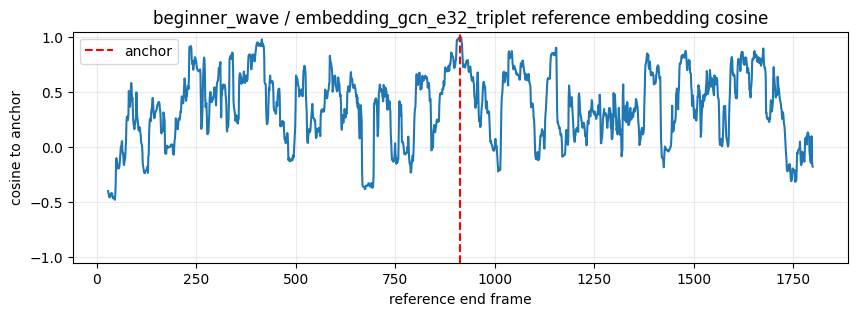

In [7]:
with np.load(CACHE_TO_CHECK, allow_pickle=True) as data:
    meta = json.loads(str(data['metadata']))
    end_indices = data['end_indices'].astype(np.int32)
    embeddings = data['embeddings'].astype(np.float32)

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_n = embeddings / np.maximum(norms, 1e-8)
anchor_idx = len(embeddings_n) // 2
sims = embeddings_n @ embeddings_n[anchor_idx]

plt.figure(figsize=(10, 3))
plt.plot(end_indices, sims)
plt.axvline(end_indices[anchor_idx], color='red', linestyle='--', label='anchor')
plt.title(f"{meta['dance_name']} / {meta['model_name']} reference embedding cosine")
plt.xlabel('reference end frame')
plt.ylabel('cosine to anchor')
plt.ylim(-1.05, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. 다음 단계

이 노트북은 cache 파일을 만드는 단계까지 담당한다.

서비스 런타임 최적화를 완성하려면 다음 단계로 `ScratchPoseSimilarity`가 현재 reference sequence와 model에 맞는 `.npz` cache를 로드하고, reference 후보마다 TFLite를 다시 호출하는 대신 cache embedding을 조회하도록 연결하면 된다.
